In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [5]:
df=pd.read_csv("/content/credit_risk_dataset.csv")

In [6]:
df.head()

,Age,Income,Loan_Amount,Loan_Duration_Months,Credit_Score,Employment_Years,Existing_Loans,Marital_Status,Housing,Loan_Purpose,Risk
0,56,125186,19546,37,454,21,1,Single,Own,Education,1
1,69,54674,20129,53,729,15,1,Married,Own,Personal,0
2,46,55854,2591,33,662,7,1,Married,Rent,Business,0
3,32,66271,12303,22,747,7,4,Divorced,Own,Car,1
4,60,93688,31561,36,533,26,4,Married,Own,Business,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   1000 non-null   int64 
 1   Income                1000 non-null   int64 
 2   Loan_Amount           1000 non-null   int64 
 3   Loan_Duration_Months  1000 non-null   int64 
 4   Credit_Score          1000 non-null   int64 
 5   Employment_Years      1000 non-null   int64 
 6   Existing_Loans        1000 non-null   int64 
 7   Marital_Status        1000 non-null   object
 8   Housing               1000 non-null   object
 9   Loan_Purpose          1000 non-null   object
 10  Risk                  1000 non-null   int64 
dtypes: int64(8), object(3)
memory usage: 86.1+ KB


In [8]:
df.isnull().sum()

,0
Age,0
Income,0
Loan_Amount,0
Loan_Duration_Months,0
Credit_Score,0
Employment_Years,0
Existing_Loans,0
Marital_Status,0
Housing,0
Loan_Purpose,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.shape

(1000, 11)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 62.48it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Profile report saved as 'credit_risk_profile_report.html'


/tmp/ipython-input-2598027544.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Risk', palette='Set2')


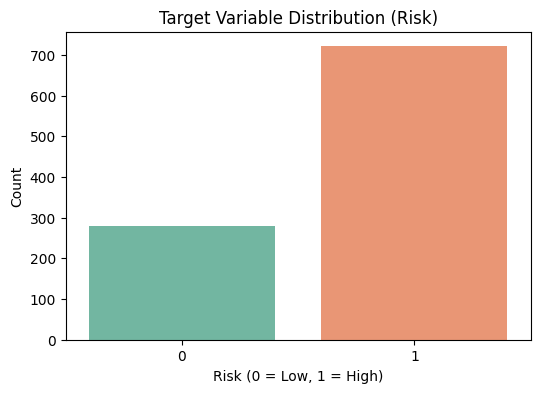

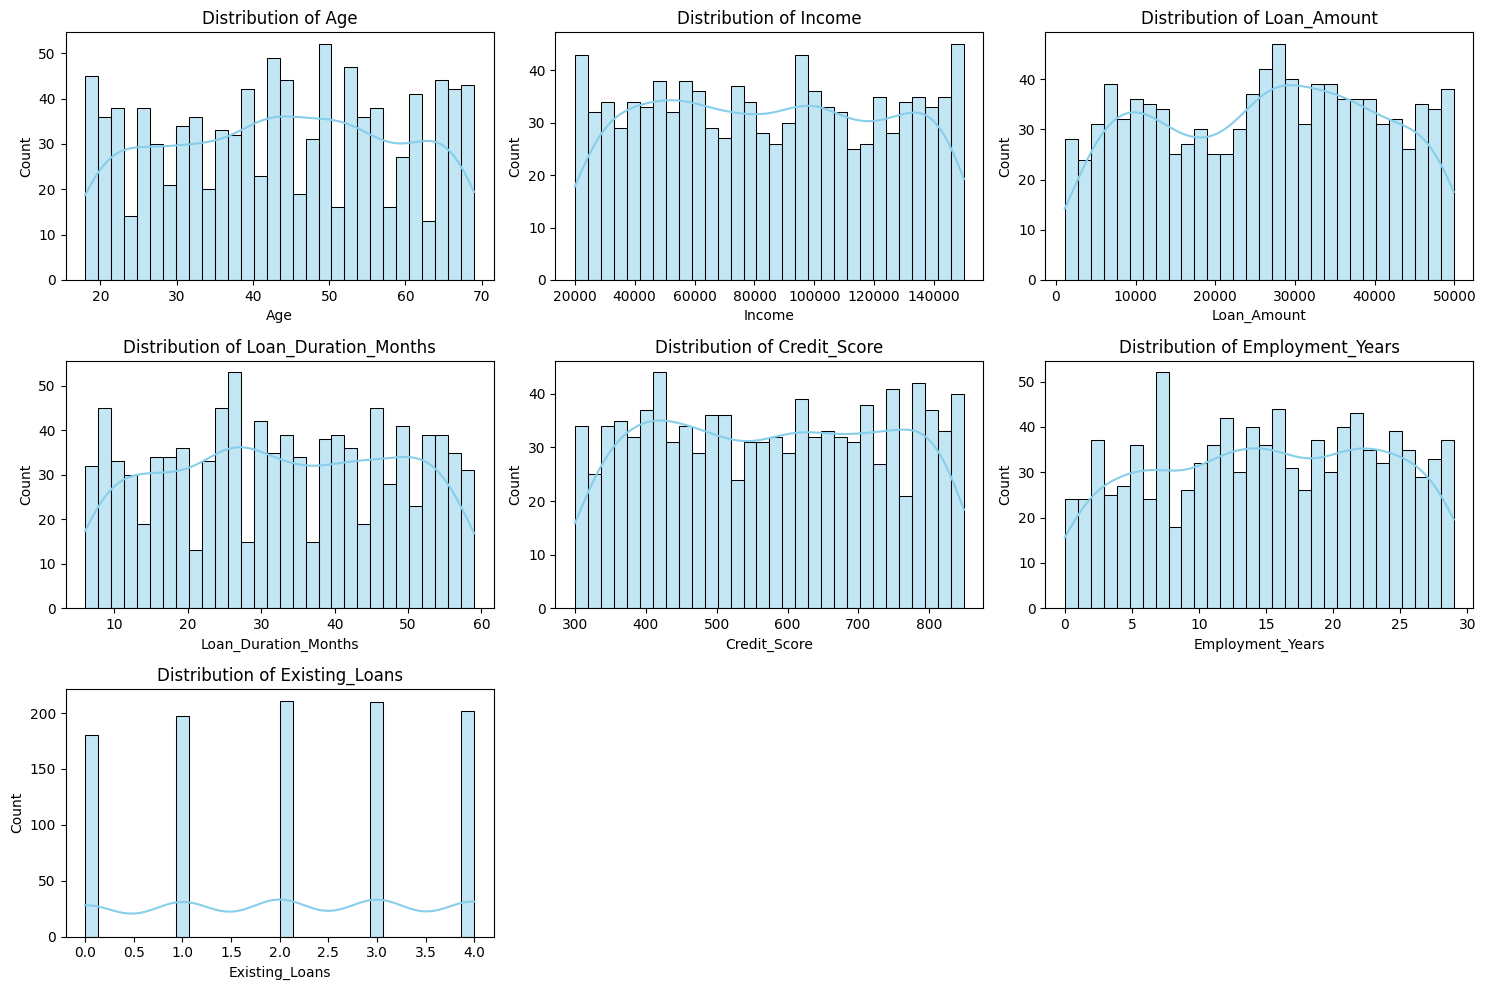

/tmp/ipython-input-2598027544.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set3')
/tmp/ipython-input-2598027544.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set3')
/tmp/ipython-input-2598027544.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='Set3')


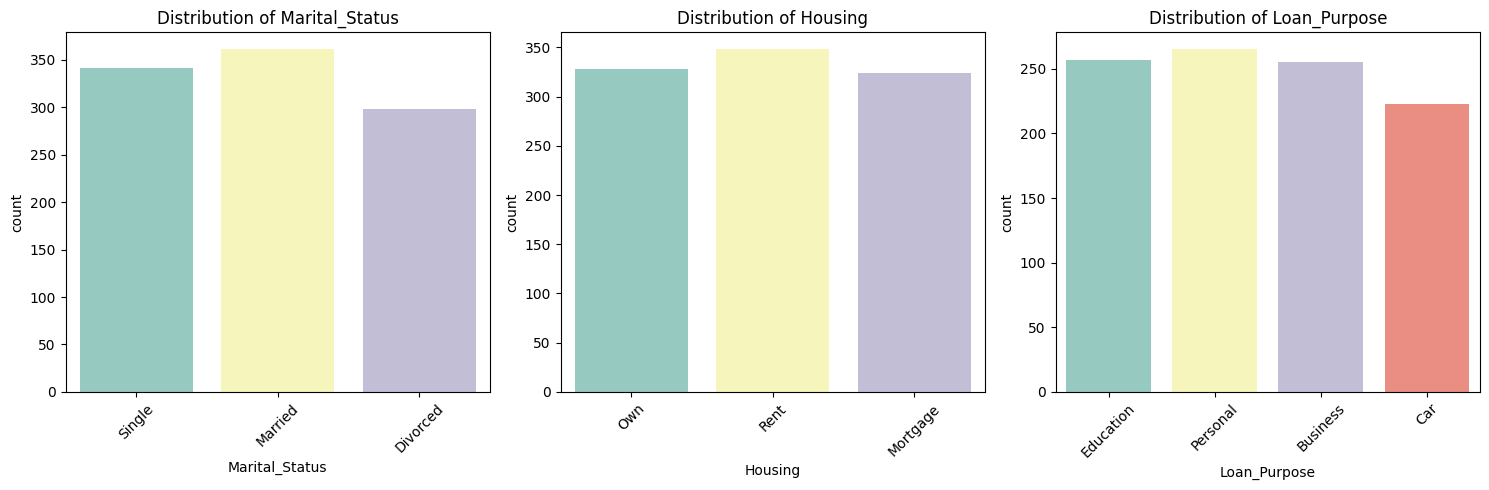

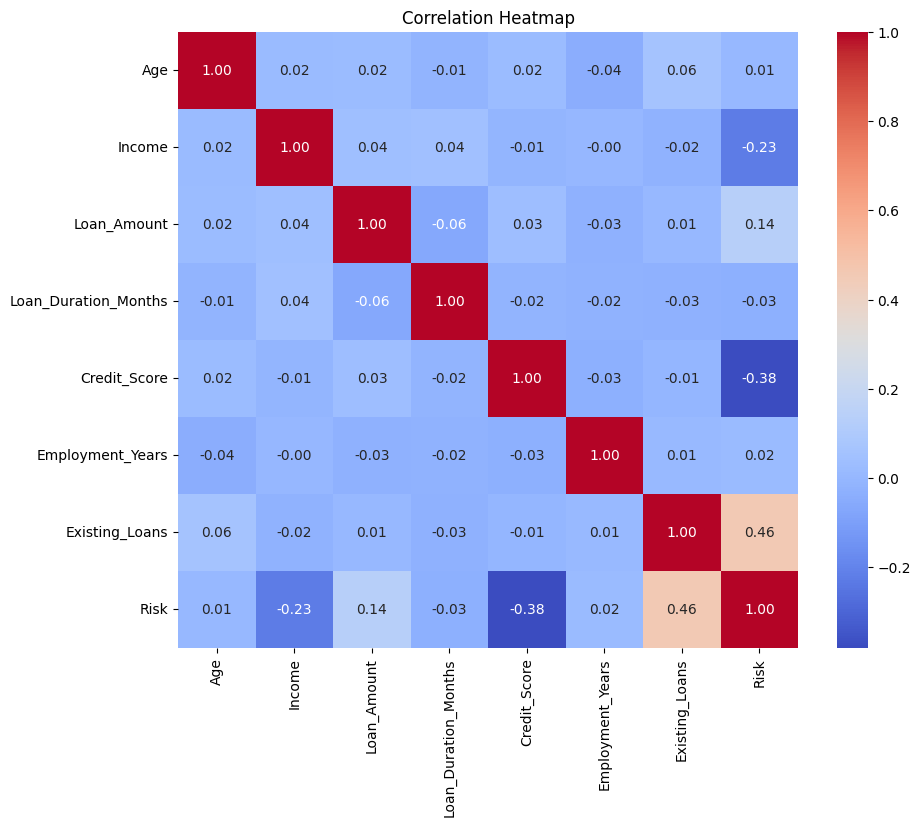

/tmp/ipython-input-2598027544.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y=col, data=df, palette='Set2')
/tmp/ipython-input-2598027544.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y=col, data=df, palette='Set2')
/tmp/ipython-input-2598027544.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Risk', y=col, data=df, palette='Set2')
/tmp/ipython-input-2598027544.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hu

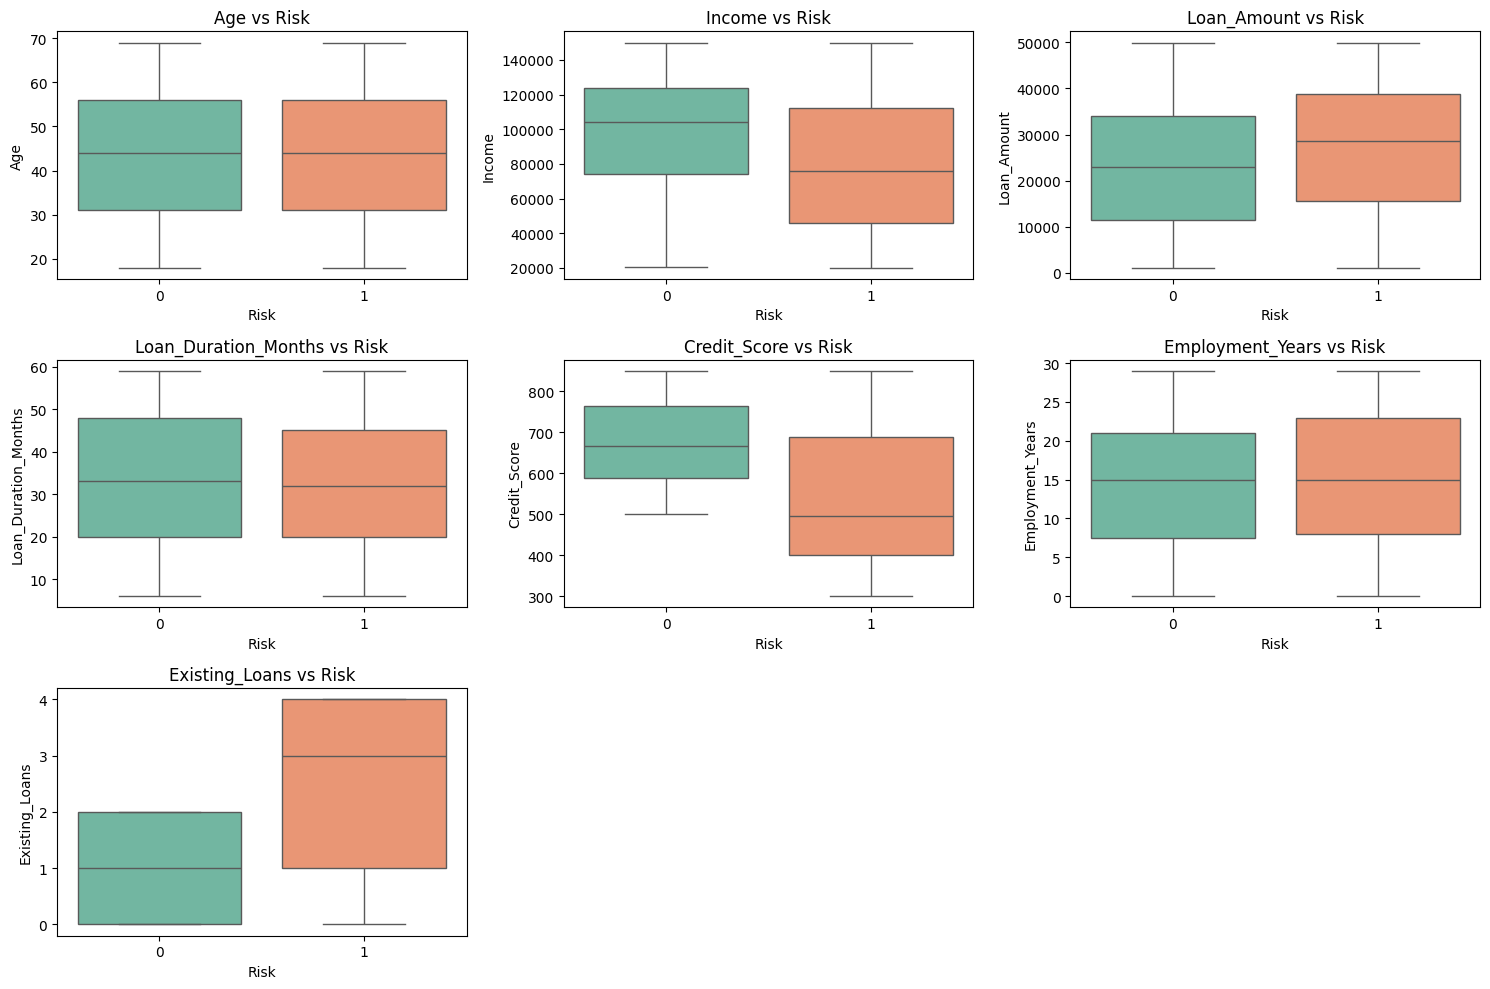

In [14]:
from ydata_profiling import ProfileReport  # formerly pandas_profiling


# ==============================================
# 4️⃣ Profile Report (Automated)
# ==============================================
profile = ProfileReport(df, title="Credit Risk Dataset Profiling Report", explorative=True)
profile.to_file("credit_risk_profile_report.html")  # Generates an HTML report
print("Profile report saved as 'credit_risk_profile_report.html'")

# ==============================================
# 5️⃣ EDA - Target Variable Distribution
# ==============================================
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Risk', palette='Set2')
plt.title('Target Variable Distribution (Risk)')
plt.xlabel('Risk (0 = Low, 1 = High)')
plt.ylabel('Count')
plt.show()

# ==============================================
# 6️⃣ EDA - Numerical Features Distribution
# ==============================================
numerical_cols = ['Age', 'Income', 'Loan_Amount', 'Loan_Duration_Months',
                  'Credit_Score', 'Employment_Years', 'Existing_Loans']

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3,3,i+1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# ==============================================
# 7️⃣ EDA - Categorical Features Distribution
# ==============================================
categorical_cols = ['Marital_Status', 'Housing', 'Loan_Purpose']

plt.figure(figsize=(15,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(data=df, x=col, palette='Set3')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==============================================
# 8️⃣ Correlation Heatmap (Numerical Features)
# ==============================================
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols + ['Risk']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# ==============================================
# 9️⃣ Risk vs Numerical Features (Boxplots)
# ==============================================
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(x='Risk', y=col, data=df, palette='Set2')
    plt.title(f'{col} vs Risk')
plt.tight_layout()
plt.show()

In [15]:
df['Risk'].value_counts()

,count
Risk,
1,721
0,279


In [25]:
X=df.drop(columns=['Risk'],axis=1)
y=df['Risk']

In [26]:

# Columns to encode
categorical_cols = ['Marital_Status', 'Housing', 'Loan_Purpose']

# One-Hot Encoding
X = pd.get_dummies(df, columns=categorical_cols, drop_first=True)  # drop_first avoids dummy variable trap

print(X.head())

   Age  Income  Loan_Amount  Loan_Duration_Months  Credit_Score  \
0   56  125186        19546                    37           454   
1   69   54674        20129                    53           729   
2   46   55854         2591                    33           662   
3   32   66271        12303                    22           747   
4   60   93688        31561                    36           533   

   Employment_Years  Existing_Loans  Risk  Marital_Status_Married  \
0                21               1     1                   False   
1                15               1     0                    True   
2                 7               1     0                    True   
3                 7               4     1                   False   
4                26               4     1                    True   

   Marital_Status_Single  Housing_Own  Housing_Rent  Loan_Purpose_Car  \
0                   True         True         False             False   
1                  False         Tru

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit(X_test)

In [29]:
X_test_scaled

StandardScaler()

In [30]:
X_train_scaled

array([[-0.12149869, -1.53054014,  1.08596993, ..., -0.53881591,
        -0.57350122,  1.64952424],
       [-1.4818759 ,  1.67621074, -0.21134053, ...,  1.85592145,
        -0.57350122, -0.60623541],
       [ 1.4429351 , -0.25876903, -1.10616996, ..., -0.53881591,
         1.74367544, -0.60623541],
       ...,
       [ 0.49067105, -0.792141  ,  1.42012565, ..., -0.53881591,
        -0.57350122,  1.64952424],
       [ 1.30689738, -0.97002688, -1.36264372, ..., -0.53881591,
        -0.57350122, -0.60623541],
       [-0.12149869,  0.59570137,  0.04875984, ..., -0.53881591,
        -0.57350122, -0.60623541]])

In [44]:
model=Sequential([
    Dense(14,input_dim=15,activation='relu'),
    Dense(16,activation='relu'),
    Dense(8,activation='relu'),
    Dense(1,activation='sigmoid')

    ])

In [45]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 14)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [55]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    batch_size=50,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 9.1740e-08 - val_accuracy: 1.0000 - val_loss: 5.4166e-07
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 1.0383e-07 - val_accuracy: 1.0000 - val_loss: 5.3221e-07
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 9.9454e-08 - val_accuracy: 1.0000 - val_loss: 5.2374e-07
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 6.7181e-08 - val_accuracy: 1.0000 - val_loss: 5.1473e-07
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 9.2196e-08 - val_accuracy: 1.0000 - val_loss: 5.0701e-07
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 8.6004e-08 - val_accuracy: 1.0000 - val_loss: 4.9672e-07
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 7.9844e-08 - val_accuracy: 1.0000 - val_loss: 4.8920e-07
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - 

In [56]:
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0000
Test Accuracy: 1.0000
